# Análisis Exploratorio de Datos (EDA)

## Análisis Financiero de las Empresas Más Grandes de Colombia

### Objetivo

Analizar la información financiera de las empresas más grandes de Colombia para identificar patrones, tendencias, diferencias entre sectores económicos y oportunidades de generación de valor.

---

**Fuente**

Superintendencia de Sociedades

**Periodo**

2024 - 2025

**Autor**

Laura Camila Rios

In [36]:
##Cargar proyecto para poder importar funciones desde src

import sys
from pathlib import Path

# Agregar la raíz del proyecto al path de Python
project_root = Path.cwd().parent
sys.path.append(str(project_root))

print(project_root)

c:\Users\USUARIO\Documents\GitHub\Empresas-Colombianas


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (10,6)

In [39]:
##Cargar archivo desde la capa Silver

from src.config import OUTPUT_FILE

df = pd.read_csv(OUTPUT_FILE)

df.head()

,ranking_2025,nit,razon_social,supervisor,región,departamento_domicilio,ciudad_domicilio,ciiu,macrosector,ingresos_operacionales_2025,ganancia_pérdida_2025,total_activos_2025,total_pasivos_2025,total_patrimonio_2025,ingresos_operacionales_2024,ganancia_pérdida_2024,total_activos_2024,total_pasivos_2024,total_patrimonio_2024,ranking_20251
0,1,899999068,ECOPETROL S.A,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,B0610 - Extracción de petróleo crudo,MINERO,100590667613,9028764859,198110860034,114350599639,83760260395,1.139233e+11,1.493470e+10,2.142410e+11,1.305441e+11,8.369690e+10,1
1,2,830095213,ORGANIZACIÓN TERPEL S.A.,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4661 - Comercio al por mayor de combustibles ...,COMERCIO,26395418332,628485892,8112318463,4699968205,3412350258,2.475201e+10,5.307560e+08,7.971212e+09,4.621825e+09,3.349387e+09,2
2,3,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,CARIBE,BOLÍVAR,CARTAGENA,C1921 - Fabricación de productos de la refinac...,MANUFACTURA,22395204745,-821398601,34946245504,11566291299,23379954205,2.586091e+10,-2.628626e+08,3.950386e+10,1.192736e+10,2.757650e+10,3
3,4,900276962,D1 S A S,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4711 - Comercio al por menor en establecimien...,COMERCIO,21606607933,418933423,6939606162,6724638908,214967254,1.943940e+10,3.732099e+08,6.321816e+09,6.104116e+09,2.177000e+08,4
4,5,890904996,EMPRESAS PÚBLICAS DE MEDELLÍN E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3513 - Distribución de energía eléctrica,SERVICIOS,20285629973,4875861363,71083399625,36111926922,34971472703,2.057448e+10,4.825909e+09,6.691806e+10,3.445552e+10,3.246254e+10,5


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ranking_2025                 10000 non-null  int64  
 1   nit                          10000 non-null  int64  
 2   razon_social                 10000 non-null  str    
 3   supervisor                   10000 non-null  str    
 4   región                       10000 non-null  str    
 5   departamento_domicilio       10000 non-null  str    
 6   ciudad_domicilio             10000 non-null  str    
 7   ciiu                         10000 non-null  str    
 8   macrosector                  10000 non-null  str    
 9   ingresos_operacionales_2025  10000 non-null  int64  
 10  ganancia_pérdida_2025        10000 non-null  int64  
 11  total_activos_2025           10000 non-null  int64  
 12  total_pasivos_2025           10000 non-null  int64  
 13  total_patrimonio_2025       

In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ranking_2025,10000.0,5.000500e+03,2.886896e+03,1.000000e+00,2.500750e+03,5000.5,7.500250e+03,1.000000e+04
nit,10000.0,8.678463e+08,4.007160e+07,8.000003e+08,8.300512e+08,891224132.0,9.005609e+08,9.019666e+08
ingresos_operacionales_2025,10000.0,1.853802e+08,1.247754e+09,2.125605e+07,3.191299e+07,51954860.0,1.136822e+08,1.005907e+11
ganancia_pérdida_2025,10000.0,1.386655e+07,1.581161e+08,-1.983319e+09,4.666448e+05,1750991.0,5.360869e+06,9.028765e+09
total_activos_2025,10000.0,2.560405e+08,2.596320e+09,3.312980e+05,1.937913e+07,40623242.0,1.066755e+08,1.981109e+11
total_pasivos_2025,10000.0,1.376665e+08,1.669713e+09,0.000000e+00,8.557942e+06,19634044.5,5.312068e+07,1.143506e+11
total_patrimonio_2025,10000.0,1.183740e+08,1.136198e+09,-1.431150e+09,6.809172e+06,16656508.5,4.498582e+07,8.376026e+10
ingresos_operacionales_2024,9999.0,1.755748e+08,1.351397e+09,0.000000e+00,2.833543e+07,47176902.0,1.047237e+08,1.139233e+11
ganancia_pérdida_2024,9999.0,1.256449e+07,2.018530e+08,-1.342691e+09,3.219695e+05,1428454.0,4.488644e+06,1.493470e+10
total_activos_2024,9947.0,2.530935e+08,2.749484e+09,0.000000e+00,1.752520e+07,37737614.0,9.967274e+07,2.142410e+11


¿Cómo se distribuyen las empresas por macrosector?

In [42]:
sector = (
    df["macrosector"]
    .value_counts()
)

sector

macrosector
COMERCIO        3718
SERVICIOS       2925
MANUFACTURA     2016
CONSTRUCCIÓN     745
AGROPECUARIO     419
MINERO           177
Name: count, dtype: int64

¿Qué departamentos concentran más empresas?

In [43]:
departamentos = (
    df["departamento_domicilio"]
    .value_counts()
)

departamentos.head(20)

departamento_domicilio
DISTRITO CAPITAL DE BOGOTÁ    4001
ANTIOQUIA                     1876
VALLE DEL CAUCA                868
CUNDINAMARCA                   805
ATLÁNTICO                      488
SANTANDER                      345
BOLÍVAR                        224
RISARALDA                      185
NORTE DE SANTANDER             165
CALDAS                         117
MAGDALENA                      112
META                           101
NARIÑO                          87
TOLIMA                          80
CAUCA                           77
HUILA                           74
QUINDÍO                         71
CÓRDOBA                         60
BOYACÁ                          56
CASANARE                        45
Name: count, dtype: int64

¿Qué regiones tienen mayor presencia empresarial?

In [44]:
df["región"].value_counts()

región
BOGOTÁ-CUNDINAMARCA    4806
ANTIOQUIA              1876
PACÍFICO               1044
CARIBE                  987
CENTRO - ORIENTE        566
EJE CAFETERO            373
LLANOS ORIENTALES       157
CENTRO                  154
AMAZONÍA                 37
Name: count, dtype: int64

¿Cuáles son las empresas con mayores ingresos?

In [45]:
top_ingresos = (
    df
    .sort_values(
        "ingresos_operacionales_2025",
        ascending=False
    )
)

top_ingresos.head(20)

,ranking_2025,nit,razon_social,supervisor,región,departamento_domicilio,ciudad_domicilio,ciiu,macrosector,ingresos_operacionales_2025,ganancia_pérdida_2025,total_activos_2025,total_pasivos_2025,total_patrimonio_2025,ingresos_operacionales_2024,ganancia_pérdida_2024,total_activos_2024,total_pasivos_2024,total_patrimonio_2024,ranking_20251
0,1,899999068,ECOPETROL S.A,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,B0610 - Extracción de petróleo crudo,MINERO,100590667613,9028764859,198110860034,114350599639,83760260395,1.139233e+11,1.493470e+10,2.142410e+11,1.305441e+11,8.369690e+10,1
1,2,830095213,ORGANIZACIÓN TERPEL S.A.,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4661 - Comercio al por mayor de combustibles ...,COMERCIO,26395418332,628485892,8112318463,4699968205,3412350258,2.475201e+10,5.307560e+08,7.971212e+09,4.621825e+09,3.349387e+09,2
2,3,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,CARIBE,BOLÍVAR,CARTAGENA,C1921 - Fabricación de productos de la refinac...,MANUFACTURA,22395204745,-821398601,34946245504,11566291299,23379954205,2.586091e+10,-2.628626e+08,3.950386e+10,1.192736e+10,2.757650e+10,3
3,4,900276962,D1 S A S,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4711 - Comercio al por menor en establecimien...,COMERCIO,21606607933,418933423,6939606162,6724638908,214967254,1.943940e+10,3.732099e+08,6.321816e+09,6.104116e+09,2.177000e+08,4
4,5,890904996,EMPRESAS PÚBLICAS DE MEDELLÍN E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3513 - Distribución de energía eléctrica,SERVICIOS,20285629973,4875861363,71083399625,36111926922,34971472703,2.057448e+10,4.825909e+09,6.691806e+10,3.445552e+10,3.246254e+10,5
5,6,890900608,ALMACENES EXITO S A,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,ENVIGADO,G4711 - Comercio al por menor en establecimien...,COMERCIO,16919897540,592108285,14275329448,7346534337,6928795111,1.607769e+10,5.478632e+07,1.390422e+10,7.215710e+09,6.688512e+09,6
6,7,900480569,JERONIMO MARTINS COLOMBIA SAS,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4711 - Comercio al por menor en establecimien...,COMERCIO,16370446955,-579417445,9566191188,9513980969,52210219,1.383118e+10,-6.012966e+08,8.203244e+09,8.158228e+09,4.501546e+07,7
7,8,800153993,COMUNICACIÓN CELULAR S.A.,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,J6120 - Actividades de telecomunicaciones inal...,SERVICIOS,16351044898,962886477,27193717134,17481520247,9712196887,1.560210e+10,6.926037e+08,2.688243e+10,1.695191e+10,9.930518e+09,8
8,9,890100577,AEROVIAS DEL CONTINENTE AMERICANO S.A. AVIANCA...,SUPERTRANSPORTE,CARIBE,ATLÁNTICO,BARRANQUILLA,H5111 - Transporte aéreo nacional de pasajeros,SERVICIOS,15120399895,895228478,19786262266,18741818531,1044443735,1.515658e+10,1.218650e+09,2.193733e+10,2.170420e+10,2.331332e+08,9
9,10,860063875,EMGESA S.A. E.S.P.,SUPERSERVICIOS,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,D3514 - Comercialización de energía eléctrica,SERVICIOS,14848164631,3030007350,29847413939,15251414413,14595999526,1.578033e+10,2.251936e+09,2.866895e+10,1.446397e+10,1.420498e+10,10


¿Cuáles son las empresas con mayores utilidades?

In [46]:
top_utilidad = (
    df
    .sort_values(
        "ganancia_pérdida_2025",
        ascending=False
    )
)

top_utilidad.head(20)

,ranking_2025,nit,razon_social,supervisor,región,departamento_domicilio,ciudad_domicilio,ciiu,macrosector,ingresos_operacionales_2025,ganancia_pérdida_2025,total_activos_2025,total_pasivos_2025,total_patrimonio_2025,ingresos_operacionales_2024,ganancia_pérdida_2024,total_activos_2024,total_pasivos_2024,total_patrimonio_2024,ranking_20251
0,1,899999068,ECOPETROL S.A,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,B0610 - Extracción de petróleo crudo,MINERO,100590667613,9028764859,198110860034,114350599639,83760260395,1.139233e+11,1.493470e+10,2.142410e+11,1.305441e+11,8.369690e+10,1
13,14,900531210,CENIT TRANSPORTE Y LOGÍSTICA DE HIDROCARBUROS ...,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,H4930 - Transporte por tuberías,SERVICIOS,9925243863,5123370713,19715124079,2856862131,16858261948,9.977736e+09,5.269484e+09,2.046089e+10,2.992479e+09,1.746841e+10,14
4,5,890904996,EMPRESAS PÚBLICAS DE MEDELLÍN E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3513 - Distribución de energía eléctrica,SERVICIOS,20285629973,4875861363,71083399625,36111926922,34971472703,2.057448e+10,4.825909e+09,6.691806e+10,3.445552e+10,3.246254e+10,5
73,74,890900266,GRUPO ARGOS S.A.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,K6613 - Otras actividades relacionadas con el ...,SERVICIOS,2489422122,4651826348,13828840310,2813310090,11015530220,3.535660e+09,2.531987e+09,2.201467e+10,3.246982e+09,1.876769e+10,74
14,15,860005224,BAVARIA Y CIA SCA,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,"C1103 - Producción de malta, elaboración de ce...",MANUFACTURA,9337111674,3340116479,13553691762,8434533779,5119157983,8.615774e+09,2.306255e+09,1.361444e+10,9.470246e+09,4.144189e+09,15
33,34,899999082,GRUPO ENERGÍA DE BOGOTÁ S.A. E.S.P.,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,D3512 - Transmisión de energía eléctrica,SERVICIOS,4262916224,3178242840,31739549151,12195854898,19543694253,3.716639e+09,2.462296e+09,3.031168e+10,1.115001e+10,1.916167e+10,34
18,19,800251163,OLEODUCTO CENTRAL S.A.,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,H4930 - Transporte por tuberías,SERVICIOS,6287230609,3072717611,6927592176,2935945402,3991646774,5.975161e+09,3.094792e+09,7.747236e+09,3.120957e+09,4.626279e+09,19
9,10,860063875,EMGESA S.A. E.S.P.,SUPERSERVICIOS,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,D3514 - Comercialización de energía eléctrica,SERVICIOS,14848164631,3030007350,29847413939,15251414413,14595999526,1.578033e+10,2.251936e+09,2.866895e+10,1.446397e+10,1.420498e+10,10
21,22,890100251,CEMENTOS ARGOS S.A,SUPERFINANCIERA,CARIBE,ATLÁNTICO,BARRANQUILLA,"C2394 - Fabricación de cemento, cal y yeso",MANUFACTURA,5964024733,2505545486,16938359333,5897131043,11041228290,8.142608e+09,5.521120e+09,1.942295e+10,5.883571e+09,1.353937e+10,22
38,39,860016610,INTERCONEXIÓN ELÉCTRICA S.A. E.S.P. - ISA,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3512 - Transmisión de energía eléctrica,SERVICIOS,3707303633,2414247630,26502266650,8660058804,17842207846,4.130986e+09,2.801293e+09,2.473799e+10,8.447200e+09,1.629080e+10,39


Empresas con pérdidas

In [47]:
perdidas = df[
    df["ganancia_pérdida_2025"] < 0
]

perdidas

,ranking_2025,nit,razon_social,supervisor,región,departamento_domicilio,ciudad_domicilio,ciiu,macrosector,ingresos_operacionales_2025,ganancia_pérdida_2025,total_activos_2025,total_pasivos_2025,total_patrimonio_2025,ingresos_operacionales_2024,ganancia_pérdida_2024,total_activos_2024,total_pasivos_2024,total_patrimonio_2024,ranking_20251
2,3,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,CARIBE,BOLÍVAR,CARTAGENA,C1921 - Fabricación de productos de la refinac...,MANUFACTURA,22395204745,-821398601,34946245504,11566291299,23379954205,2.586091e+10,-262862567.0,3.950386e+10,1.192736e+10,2.757650e+10,3
6,7,900480569,JERONIMO MARTINS COLOMBIA SAS,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4711 - Comercio al por menor en establecimien...,COMERCIO,16370446955,-579417445,9566191188,9513980969,52210219,1.383118e+10,-601296636.0,8.203244e+09,8.158228e+09,4.501546e+07,7
20,21,830122566,COLOMBIA TELECOMUNICACIONES S.A. E.S.P. - tele...,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,J6110 - Actividades de telecomunicaciones alám...,SERVICIOS,6194652175,-1608562240,14305285743,12357137862,1948147881,6.673470e+09,-466957341.0,1.448635e+10,1.096351e+10,3.522835e+09,21
22,23,901380949,CARIBEMAR DE LA COSTA S.A.S. E.S.P.,SUPERSERVICIOS,CARIBE,BOLÍVAR,CARTAGENA,D3514 - Comercialización de energía eléctrica,SERVICIOS,5612728005,-672503766,7406564025,4598371427,2808192598,6.351549e+09,-253414590.0,7.228846e+09,3.746420e+09,3.482426e+09,23
25,26,890903858,INDUSTRIA NACIONAL DE GASEOSAS S.A.,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,"C1104 - Elaboración de bebidas no alcohólicas,...",MANUFACTURA,5317414943,-1162898,3427100045,2645759712,781340333,5.191374e+09,-45444421.0,3.179246e+09,2.421278e+09,7.579676e+08,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9962,9963,900750184,JOWAT ANDINA S.A.S.,SUPERSOCIEDADES,ANTIOQUIA,ANTIOQUIA,ITAGUI-ANTIOQUIA,G4649 - Comercio al por mayor de otros utensil...,COMERCIO,21387805,-7678500,14821999,15860129,-1038130,2.523958e+07,423583.0,1.218074e+07,5.540370e+06,6.640370e+06,9963
9966,9967,830016372,RAVAGO DE COLOMBIA S.A.S.,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4664 - Comercio al por mayor de productos quí...,COMERCIO,21367914,-544494,15326884,2912357,12414527,1.649804e+07,1564019.0,1.672077e+07,3.761745e+06,1.295902e+07,9967
9984,9985,810001366,BIOSERVICIOS SAS,SUPERSOCIEDADES,EJE CAFETERO,CALDAS,MANIZALES-CALDAS,N8129 - Otras actividades de limpieza de edifi...,SERVICIOS,21318208,-141233,4969288,2812495,2156793,2.006183e+07,159386.0,4.894405e+06,2.530416e+06,2.363989e+06,9985
9992,9993,900242864,CARBONES TERMICOS Y COQUIZANTES S.A.S.,SUPERSOCIEDADES,CENTRO - ORIENTE,NORTE DE SANTANDER,CUCUTA-NORTE DE SANTANDER,G4661 - Comercio al por mayor de combustibles ...,COMERCIO,21287133,-1140222,44080869,8346880,35733989,6.133139e+07,3166394.0,4.293219e+07,6.057978e+06,3.687421e+07,9993


Top empresas por activos

In [48]:
df.sort_values(
    "total_activos_2025",
    ascending=False
).head(20)

,ranking_2025,nit,razon_social,supervisor,región,departamento_domicilio,ciudad_domicilio,ciiu,macrosector,ingresos_operacionales_2025,ganancia_pérdida_2025,total_activos_2025,total_pasivos_2025,total_patrimonio_2025,ingresos_operacionales_2024,ganancia_pérdida_2024,total_activos_2024,total_pasivos_2024,total_patrimonio_2024,ranking_20251
0,1,899999068,ECOPETROL S.A,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,B0610 - Extracción de petróleo crudo,MINERO,100590667613,9028764859,198110860034,114350599639,83760260395,1.139233e+11,1.493470e+10,2.142410e+11,1.305441e+11,8.369690e+10,1
7287,7288,901343268,ELECTRIBUS BOGOTÁ USME I S.A.S,SUPERTRANSPORTE,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,"BOGOTÁ, D.C.",H4923 - Transporte de carga por carretera,SERVICIOS,33141635,1632553,102519674096,100204859825,2314813972,3.233602e+07,2.806758e+05,1.068340e+11,1.047425e+11,2.091489e+09,7288
4,5,890904996,EMPRESAS PÚBLICAS DE MEDELLÍN E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3513 - Distribución de energía eléctrica,SERVICIOS,20285629973,4875861363,71083399625,36111926922,34971472703,2.057448e+10,4.825909e+09,6.691806e+10,3.445552e+10,3.246254e+10,5
2,3,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,CARIBE,BOLÍVAR,CARTAGENA,C1921 - Fabricación de productos de la refinac...,MANUFACTURA,22395204745,-821398601,34946245504,11566291299,23379954205,2.586091e+10,-2.628626e+08,3.950386e+10,1.192736e+10,2.757650e+10,3
33,34,899999082,GRUPO ENERGÍA DE BOGOTÁ S.A. E.S.P.,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,D3512 - Transmisión de energía eléctrica,SERVICIOS,4262916224,3178242840,31739549151,12195854898,19543694253,3.716639e+09,2.462296e+09,3.031168e+10,1.115001e+10,1.916167e+10,34
9,10,860063875,EMGESA S.A. E.S.P.,SUPERSERVICIOS,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,D3514 - Comercialización de energía eléctrica,SERVICIOS,14848164631,3030007350,29847413939,15251414413,14595999526,1.578033e+10,2.251936e+09,2.866895e+10,1.446397e+10,1.420498e+10,10
7,8,800153993,COMUNICACIÓN CELULAR S.A.,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,J6120 - Actividades de telecomunicaciones inal...,SERVICIOS,16351044898,962886477,27193717134,17481520247,9712196887,1.560210e+10,6.926037e+08,2.688243e+10,1.695191e+10,9.930518e+09,8
38,39,860016610,INTERCONEXIÓN ELÉCTRICA S.A. E.S.P. - ISA,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3512 - Transmisión de energía eléctrica,SERVICIOS,3707303633,2414247630,26502266650,8660058804,17842207846,4.130986e+09,2.801293e+09,2.473799e+10,8.447200e+09,1.629080e+10,39
26,27,811000740,ISAGEN S.A. E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3511 - Generación de energia electrica,SERVICIOS,5242488560,882203227,25989635428,20066450131,5923185297,6.135599e+09,9.046156e+08,2.429324e+10,1.873166e+10,5.561582e+09,27
132,133,811012271,GRUPO DE INVERSIONES SURAMERICANA S.A.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,K6613 - Otras actividades relacionadas con el ...,SERVICIOS,1633661831,1641953241,23588564777,8033946361,15554618416,1.245135e+09,5.331776e+09,3.096469e+10,9.532479e+09,2.143221e+10,133


Empresas con mayor patrimonio

In [49]:
df.sort_values(
    "total_patrimonio_2025",
    ascending=False
).head(20)

,ranking_2025,nit,razon_social,supervisor,región,departamento_domicilio,ciudad_domicilio,ciiu,macrosector,ingresos_operacionales_2025,ganancia_pérdida_2025,total_activos_2025,total_pasivos_2025,total_patrimonio_2025,ingresos_operacionales_2024,ganancia_pérdida_2024,total_activos_2024,total_pasivos_2024,total_patrimonio_2024,ranking_20251
0,1,899999068,ECOPETROL S.A,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,B0610 - Extracción de petróleo crudo,MINERO,100590667613,9028764859,198110860034,114350599639,83760260395,1.139233e+11,1.493470e+10,2.142410e+11,1.305441e+11,8.369690e+10,1
4,5,890904996,EMPRESAS PÚBLICAS DE MEDELLÍN E.S.P.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3513 - Distribución de energía eléctrica,SERVICIOS,20285629973,4875861363,71083399625,36111926922,34971472703,2.057448e+10,4.825909e+09,6.691806e+10,3.445552e+10,3.246254e+10,5
2,3,900112515,REFINERIA DE CARTAGENA S.A.,SUPERSERVICIOS,CARIBE,BOLÍVAR,CARTAGENA,C1921 - Fabricación de productos de la refinac...,MANUFACTURA,22395204745,-821398601,34946245504,11566291299,23379954205,2.586091e+10,-2.628626e+08,3.950386e+10,1.192736e+10,2.757650e+10,3
33,34,899999082,GRUPO ENERGÍA DE BOGOTÁ S.A. E.S.P.,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,D3512 - Transmisión de energía eléctrica,SERVICIOS,4262916224,3178242840,31739549151,12195854898,19543694253,3.716639e+09,2.462296e+09,3.031168e+10,1.115001e+10,1.916167e+10,34
697,698,800216181,GRUPO AVAL ACCIONES Y VALORES S A,SUPERFINANCIERA,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,G4799 - Otros tipos de comercio al por menor n...,COMERCIO,426403553,339435396,21784589217,2836221699,18948367518,1.376774e+09,9.998861e+08,2.094024e+10,2.971539e+09,1.796870e+10,698
38,39,860016610,INTERCONEXIÓN ELÉCTRICA S.A. E.S.P. - ISA,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,D3512 - Transmisión de energía eléctrica,SERVICIOS,3707303633,2414247630,26502266650,8660058804,17842207846,4.130986e+09,2.801293e+09,2.473799e+10,8.447200e+09,1.629080e+10,39
148,149,901351676,GRUPO BICENTENARIO SAS,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,M7010 - Actividades de administración empresarial,SERVICIOS,1521062818,1395321202,18122071447,397121125,17724950322,1.620739e+09,1.654425e+09,1.771023e+10,4.985130e+07,1.766038e+10,149
13,14,900531210,CENIT TRANSPORTE Y LOGÍSTICA DE HIDROCARBUROS ...,SUPERSOCIEDADES,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,H4930 - Transporte por tuberías,SERVICIOS,9925243863,5123370713,19715124079,2856862131,16858261948,9.977736e+09,5.269484e+09,2.046089e+10,2.992479e+09,1.746841e+10,14
132,133,811012271,GRUPO DE INVERSIONES SURAMERICANA S.A.,SUPERFINANCIERA,ANTIOQUIA,ANTIOQUIA,MEDELLIN,K6613 - Otras actividades relacionadas con el ...,SERVICIOS,1633661831,1641953241,23588564777,8033946361,15554618416,1.245135e+09,5.331776e+09,3.096469e+10,9.532479e+09,2.143221e+10,133
9,10,860063875,EMGESA S.A. E.S.P.,SUPERSERVICIOS,BOGOTÁ-CUNDINAMARCA,DISTRITO CAPITAL DE BOGOTÁ,BOGOTA D.C.,D3514 - Comercialización de energía eléctrica,SERVICIOS,14848164631,3030007350,29847413939,15251414413,14595999526,1.578033e+10,2.251936e+09,2.866895e+10,1.446397e+10,1.420498e+10,10


Comparación 2024 vs 2025

In [50]:
df["crecimiento_ingresos"] = (
    (
        df["ingresos_operacionales_2025"]
        -
        df["ingresos_operacionales_2024"]
    )
    /
    df["ingresos_operacionales_2024"]
) * 100

### Indicadores financieros

In [51]:
# Crecimiento de ingresos (%)
df["crecimiento_ingresos_pct"] = (
    (df["ingresos_operacionales_2025"] - df["ingresos_operacionales_2024"])
    / df["ingresos_operacionales_2024"]
) * 100

# Margen de utilidad (%)
df["margen_utilidad_pct"] = (
    df["ganancia_pérdida_2025"]
    / df["ingresos_operacionales_2025"]
) * 100

# Endeudamiento (%)
df["endeudamiento_pct"] = (
    df["total_pasivos_2025"]
    / df["total_activos_2025"]
) * 100

# ROA (%)
df["roa_pct"] = (
    df["ganancia_pérdida_2025"]
    / df["total_activos_2025"]
) * 100

# ROE (%)
df["roe_pct"] = (
    df["ganancia_pérdida_2025"]
    / df["total_patrimonio_2025"]
) * 100

In [52]:
## Matriz de correlación entre variables numéricas de interés

import matplotlib.pyplot as plt

# Variables numéricas de interés
variables = [
    "ingresos_operacionales_2025",
    "ganancia_pérdida_2025",
    "total_activos_2025",
    "total_pasivos_2025",
    "total_patrimonio_2025",
    "crecimiento_ingresos_pct",
    "margen_utilidad_pct",
    "endeudamiento_pct",
    "roa_pct",
    "roe_pct"
]

correlacion = df[variables].corr()

correlacion

,ingresos_operacionales_2025,ganancia_pérdida_2025,total_activos_2025,total_pasivos_2025,total_patrimonio_2025,crecimiento_ingresos_pct,margen_utilidad_pct,endeudamiento_pct,roa_pct,roe_pct
ingresos_operacionales_2025,1.000000,0.665534,0.817631,0.724094,0.804262,-0.001673,0.008407,0.011024,0.000593,-0.003136
ganancia_pérdida_2025,0.665534,1.000000,0.716901,0.564401,0.808763,0.000267,0.175691,-0.031276,0.084766,0.007898
total_activos_2025,0.817631,0.716901,1.000000,0.950134,0.888813,0.000943,0.058569,-0.003030,-0.005364,-0.002628
total_pasivos_2025,0.724094,0.564401,0.950134,1.000000,0.701585,-0.000891,0.012404,0.022214,-0.013813,-0.002754
total_patrimonio_2025,0.804262,0.808763,0.888813,0.701585,1.000000,0.003464,0.115609,-0.039570,0.008043,-0.001957
crecimiento_ingresos_pct,-0.001673,0.000267,0.000943,-0.000891,0.003464,1.000000,0.015751,0.002037,-0.003892,0.000167
margen_utilidad_pct,0.008407,0.175691,0.058569,0.012404,0.115609,0.015751,1.000000,-0.146764,0.349686,0.028039
endeudamiento_pct,0.011024,-0.031276,-0.003030,0.022214,-0.039570,0.002037,-0.146764,1.000000,-0.189422,0.010080
roa_pct,0.000593,0.084766,-0.005364,-0.013813,0.008043,-0.003892,0.349686,-0.189422,1.000000,0.086436
roe_pct,-0.003136,0.007898,-0.002628,-0.002754,-0.001957,0.000167,0.028039,0.010080,0.086436,1.000000


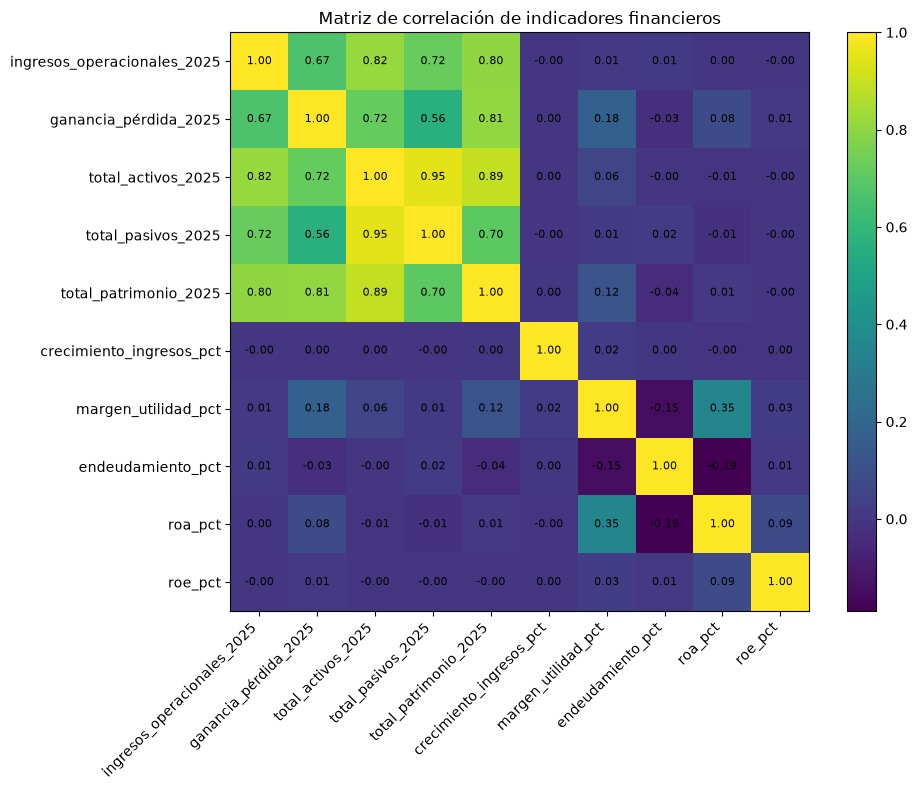

In [53]:
import matplotlib.pyplot as plt
import numpy as np

corr = df[variables].corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr.values)

ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Mostrar el valor de cada correlación
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im)
plt.title("Matriz de correlación de indicadores financieros")
plt.tight_layout()
plt.show()

### Hallazgos

- Los sectores que concentran mayor cantidad de empresas son comercio, servicios y manufactura.

- Bogotá concentra 4806 empresas, siendo la primera región en contener la mayor cantidad de empresas.

- Ecopetrol lidera la lista como empresa con mayor cantidad de ingresos y utilidades, así mismo, es la empresa con mayor cantidad de activos y patrimonio.

- Se identificaron algunas empresas con perdidas, destacando en primer lugar la refineria de cartagena.

- Existen diferencias entre algunos sectores, por ejemplo el sector minero en comparación con los sectores que contienen la mayor cantidad de empresas, lo que evidencia que este sector es mucho más controlado teniendo en cuenta que afecta directamente al medio ambiente.

- Teniendo en cuenta la matriz de correlación, se puede observar que los ingresos, las utilidades y los activos estan directamente relacionados con el patrimonio de las empresas.